# SCADA Functionality Test Visualiser

**Author:** Erick Chauke

SCADA stands for Supervisory Control and Data Acquisition, the system that runs a power plant and logs its measurements every second. Each grid-code functionality test leaves one of these logger spreadsheets, and today every one is checked by eye against the acceptance procedure. This notebook starts to automate that. Drop a test export into `data/`, run the notebook, and it parses the channels, compares the measured values against their setpoints and control modes, and plots whether the plant met each part of the procedure. The procedure is the SCADA Functionality Test Record (Rev 3) from NCSS, the National Control System Support group of the grid operator [1]. It is built to be general, so nothing is tied to one site. The single config cell below is all that changes between tests, and new sections are added one at a time. The first is the curtailment test.

## Setup

The config cell below is the only thing you edit. To run a new test, drop its spreadsheet into `data/` and run all cells. It locates the workbook, sets the site, time zone and highlighted event windows, and creates `outputs/`. Each figure is saved there with a short form of the site name as a prefix, so results from different plants never overwrite one another.

In [1]:
# Single config cell. To point this notebook at a different test, drop the new
# spreadsheet into the data/ folder and (only if more than one file is present)
# adjust INPUT_GLOB below. Nothing else in the notebook is edited to swap sites.

import re
from pathlib import Path

DATA_DIR = Path("data")          # input files live here (gitignored)
INPUT_GLOB = "*.xlsx"            # pattern that selects the logger workbook
OUTPUT_DIR = Path("outputs")     # every figure is saved here

SITE_NAME = "Hartebeesthoek"     # plant name shown in titles
TIME_ZONE_LABEL = "UTC"         # the logger timestamps are in this zone

# Optional scope restriction per test. Each section finds every occurrence of its test on
# its own, so leave an entry as None to scan the whole record (the normal case). Set a
# (start, end) pair only if you want to limit a test to one part of the day. The ceiling,
# ramp rates and exact times are always read from the data, never hard-coded.
EVENT_WINDOWS = {
    "curtailment": None,
    "power_gradient": None,
    "frequency": None,
    "delta": None,
}

# Frequency response thresholds. These are the only frequency values supplied by hand,
# because the test sheet does not record them. They come from the South African Grid Code
# requirements for renewable power plants [2]: above the over-frequency point the plant
# must start reducing power, and above the trip point held for the trip hold time it must
# disconnect. The droop is read from the sheet, not set here, and the nominal frequency is
# read from the measured grid frequency.
F4_OVER_FREQUENCY_HZ = 50.5   # over-frequency point where power reduction must begin
F5_TRIP_HZ = 51.5             # trip point above which the plant must disconnect
TRIP_HOLD_SECONDS = 4         # seconds above the trip point before disconnection is required

# Delta production constraint grid-code parameters, supplied by hand from the SAGC [2]
# because the sheet does not record them. Delta is the reserve the plant holds back, as a
# percentage of its available power.
DELTA_ACCURACY_PERCENT = 2.0       # delivered reduction must match the setpoint within this
DELTA_COMMENCE_SECONDS = 2         # the change must start within this many seconds of the order
DELTA_COMPLETE_SECONDS = 10        # the change must finish within this many seconds of the order
DELTA_MIN_CAPABILITY_PERCENT = 3   # the plant must be capable of at least this delta

# Escape hatch for odd spreadsheets. The notebook normally finds each channel on its
# own, but if it ever guesses wrong, map the role to the exact column name here and it
# takes priority. Roles: poc_p, sp_p, ap_mode, pg_mode, ramp_up, ramp_down, f_control,
# grid_freq, droop_f, delta_mode, delta_sp, timestamp, date, time. Example:
#   COLUMN_OVERRIDES = {"poc_p": "Active Power MW"}
COLUMN_OVERRIDES = {}

# Resolve the single input workbook without hard-coding its (confidential) name.
_candidates = sorted(DATA_DIR.glob(INPUT_GLOB))
assert len(_candidates) >= 1, f"no file matching {INPUT_GLOB} found in {DATA_DIR}"
INPUT_FILE = _candidates[0]

# Namespace saved figures by a safe slug of the site name, never the raw (and
# confidential) file name, so outputs from different sites never overwrite one
# another and no committed figure leaks the source file name.
SITE_SLUG = re.sub(r"[^0-9a-zA-Z]+", "_", SITE_NAME).strip("_").lower()

OUTPUT_DIR.mkdir(exist_ok=True)
_scope = {k: v for k, v in EVENT_WINDOWS.items() if v}
print(f"Site: {SITE_NAME} | timezone: {TIME_ZONE_LABEL}")
print(f"Input workbook resolved from {DATA_DIR}/ ({len(_candidates)} match)")
print(f"Figures will be saved to {OUTPUT_DIR}/ with prefix '{SITE_SLUG}_'")
print(f"Test scope overrides: {_scope or 'none, scanning the whole record'}")
print(f"Column overrides: {COLUMN_OVERRIDES or 'none'}")

Site: Hartebeesthoek | timezone: UTC
Input workbook resolved from data/ (1 match)
Figures will be saved to outputs/ with prefix 'hartebeesthoek_'
Test scope overrides: none, scanning the whole record
Column overrides: none


## Data ingestion and inspection

Before trusting any figure, this section loads the workbook and reports what is inside it: how many sheets there are, the row and column counts, and the type of each column. When a workbook has several sheets the largest one is taken as the logged time series. Sheet names are not printed, because they can carry identifiers that should stay confidential. The output here is a structural check rather than a plot, and it is the moment to confirm the data matches what the test was meant to capture.

In [2]:
import pandas as pd

# Load every sheet so the real structure is confirmed before any narrative is built on
# it. sheet_name=None keeps a multi-sheet workbook from being reduced to its first tab,
# and na_values catches the string sentinels Excel exports leave behind.
sheets = pd.read_excel(INPUT_FILE, sheet_name=None, na_values=["NULL", "None", "NaN", ""])

print(f"Sheets found: {len(sheets)}")
for i, frame in enumerate(sheets.values(), start=1):
    print(f"  sheet {i}: {frame.shape[0]} rows x {frame.shape[1]} columns")

# Work from the sheet with the most rows, which is the logged time series. Sheet names
# are deliberately not printed, as they can carry confidential identifiers.
raw = max(sheets.values(), key=len)
print(f"\nUsing the largest sheet: {raw.shape[0]} rows x {raw.shape[1]} columns")

print("\nColumns and dtypes:")
for col, dtype in raw.dtypes.items():
    print(f"  {col:<26} {dtype}")

Sheets found: 1
  sheet 1: 7147 rows x 23 columns

Using the largest sheet: 7147 rows x 23 columns

Columns and dtypes:
  Date                       datetime64[ns]
  Time UTC(NC2)              object
  POC: P (MW)                float64
  POC: Q (MVAr)              float64
  POC: Freq (Hz)             float64
  POC: PF                    float64
  POC: Average Voltage (KV)  float64
  SP: P (MW)                 int64
  SP: Q (MVAr)               int64
  SP:Voltage (kV)            int64
  SP: PF                     int64
  SP: P-Delta (%)            int64
  f used by f control (during test) float64
  SP:Ramp up (MW/min)        int64
  SP:Ramp down (MW/min)      int64
  Mode:Q                     int64
  Mode:V                     int64
  Mode:PF                    int64
  Mode: Active Power         int64
  Mode: p-Delta              int64
  Mode: Power Gradient       int64
  SP:Droop V (%)             int64
  SP:Droop F (%)             int64


## Data cleaning, parsing and channel resolution

Different sites do not label their columns identically, so the notebook does not assume fixed names. Each value it needs is described by a role, such as the measured active power, the active-power setpoint, the curtailment-mode flag, and the date and time. A small resolver then matches that role to whatever column carries it, ignoring case, spacing and punctuation. If a match is ever wrong, the real name can be forced through `COLUMN_OVERRIDES` in the config cell.

With the columns resolved, the cleaning runs. The time of day is read whether it arrives as a quoted string, a plain time, a full datetime or an Excel fraction of a day, then joined to the date to form the timestamp index. Columns that hold only zero and one become off and on flags, and every other channel is forced to a number so stray text turns into a missing value. The printout reports what was resolved and the time span, without showing any raw rows.

In [3]:
# --- Channel resolution -------------------------------------------------------
# Sites label columns differently, so each logical channel (its role) is matched to
# whatever column carries it, ignoring case, spacing and punctuation. If a guess is
# ever wrong, set the real name in COLUMN_OVERRIDES in the config cell and it wins.

def _norm(name):
    # Lower-case, then turn any run of non-alphanumeric characters into one space.
    return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9]+", " ", str(name).lower())).strip()

CHANNEL_PATTERNS = {
    "timestamp": [r"date.*time", r"\btimestamp\b", r"\bdatetime\b"],
    "date":      [r"\bdate\b"],
    "time":      [r"\btime\b"],
    "poc_p":     [r"poc.*\bp\b.*mw", r"poc.*active power", r"active power.*poc",
                  r"measured.*\bp\b.*mw"],
    "sp_p":      [r"\bsp\b.*\bp\b.*mw", r"set ?point.*\bp\b.*mw", r"\bp\b.*set ?point"],
    "ap_mode":   [r"mode.*active power", r"active power.*mode", r"curtail.*mode",
                  r"mode.*curtail"],
    "pg_mode":   [r"mode.*power gradient", r"power gradient.*mode", r"mode.*gradient",
                  r"gradient.*mode"],
    "ramp_up":   [r"ramp up", r"up ramp", r"ramp.*up.*min"],
    "ramp_down": [r"ramp down", r"down ramp", r"ramp.*down.*min"],
    "f_control": [r"f used", r"f control"],
    "grid_freq": [r"poc.*freq", r"grid.*freq", r"measured.*freq"],
    "droop_f":   [r"droop f", r"droop.*\bf\b"],
    "delta_mode": [r"mode.*delta", r"delta.*mode"],
    "delta_sp":   [r"sp.*delta", r"\bp delta\b", r"set ?point.*delta"],
}

_norms = {col: _norm(col) for col in raw.columns}

def resolve(role, required=False):
    override = COLUMN_OVERRIDES.get(role)
    if override is not None:
        if override not in raw.columns:
            raise KeyError(f"COLUMN_OVERRIDES['{role}'] = '{override}' is not a column")
        return override
    for pattern in CHANNEL_PATTERNS.get(role, []):
        for col, norm in _norms.items():
            if re.search(pattern, norm):
                return col
    if required:
        raise KeyError(
            f"could not find a column for the '{role}' channel. Set "
            f"COLUMN_OVERRIDES['{role}'] in the config cell to one of: {list(raw.columns)}"
        )
    return None

def _parse_time_of_day(series):
    # Time of day may be a quoted string ('08:00:47'), a plain time string, a datetime,
    # or an Excel fraction of a day. Try each in turn.
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_timedelta(series, unit="D")
    s = series.astype(str).str.strip().str.strip("'\"")
    td = pd.to_timedelta(s, errors="coerce")
    if td.notna().any():
        return td
    dt = pd.to_datetime(s, errors="coerce")
    return dt - dt.dt.normalize()

# --- Build the working frame and its timestamp index --------------------------
df = raw.copy()

ts_col = resolve("timestamp")
if ts_col is not None:
    index = pd.to_datetime(df[ts_col], errors="coerce")
    source = f"combined column '{ts_col}'"
    df = df.drop(columns=[ts_col])
else:
    date_col = resolve("date", required=True)
    time_col = resolve("time")
    if pd.api.types.is_numeric_dtype(df[date_col]):
        # Plain numbers in a date column are Excel serial days.
        date_part = pd.to_datetime(df[date_col], unit="D", origin="1899-12-30", errors="coerce")
    else:
        date_part = pd.to_datetime(df[date_col], errors="coerce")
    date_part = date_part.dt.normalize()
    if time_col is not None and time_col != date_col:
        index = date_part + _parse_time_of_day(df[time_col])
        source = f"'{date_col}' plus '{time_col}'"
        df = df.drop(columns=[c for c in {date_col, time_col} if c in df.columns])
    else:
        index = date_part
        source = f"'{date_col}' alone (no separate time column found)"
        df = df.drop(columns=[date_col])

if index.isna().all():
    raise ValueError("could not parse any timestamps; check the date and time columns "
                     "or set COLUMN_OVERRIDES in the config cell")
df.index = pd.DatetimeIndex(index, name="timestamp")
df = df[~df.index.isna()].sort_index()

# --- Column types -------------------------------------------------------------
# A column is an on/off flag only if its name looks like one (mode, flag, status,
# enable) and its values are binary. The name test stops a setpoint that happens to be
# constant or binary in one capture from being mistaken for a flag.
def _is_flag(name, col):
    looks_like_flag = any(k in _norm(name) for k in ["mode", "flag", "status", "enable"])
    vals = set(pd.unique(col.dropna()))
    binary = 0 < len(vals) <= 2 and vals <= {0, 1, True, False, 0.0, 1.0, "0", "1"}
    return looks_like_flag and binary

mode_cols = [c for c in df.columns if _is_flag(c, df[c])]
df[mode_cols] = df[mode_cols].astype(float).astype(bool)

measure_cols = [c for c in df.columns if c not in mode_cols]
df[measure_cols] = df[measure_cols].apply(pd.to_numeric, errors="coerce")

# --- Shared helpers reused by every test section ------------------------------
def on_segments(flag):
    # Every period where an on/off flag is on, as a list of (start, end) times. start is
    # the first on sample; end is where it goes off again. This is how each test finds
    # all of its windows by itself, so a test repeated in one sheet gives one graph each.
    flag = flag.astype(bool)
    spans, start = [], None
    for ts, v in flag.items():
        if v and start is None:
            start = ts
        elif not v and start is not None:
            spans.append((start, ts)); start = None
    if start is not None:
        spans.append((start, flag.index[-1]))
    return spans

def window_around(start, end, before="90s", after="90s"):
    # A slice of df padded around a window and clipped to the data, so the setpoint-sent
    # lead-in and the recovery tail are both visible on the plot.
    lo = max(df.index[0], start - pd.Timedelta(before))
    hi = min(df.index[-1], end + pd.Timedelta(after))
    return df.loc[lo:hi]

def mark_events(ax, events, y, gap=6.0, fontsize=8.5):
    # Draw a dotted vertical line at each (time, colour, label) and write the label above
    # it, lifting every second one so neighbouring labels do not overlap.
    for i, (ts, colour, text) in enumerate(events):
        ax.axvline(ts, color=colour, ls=":", lw=1.3)
        ax.annotate(text, xy=(ts, y), xytext=(ts, y + 2 + (i % 2) * gap),
                    ha="center", va="bottom", fontsize=fontsize, color=colour, fontweight="bold")

# --- Report (no raw rows or identifiers are printed) --------------------------
step = df.index.to_series().diff().median()
print(f"Timestamp index built from {source}")
print(f"Parsed {len(df)} rows spanning {df.index.min()} to {df.index.max()} {TIME_ZONE_LABEL}")
print(f"Median sample step: {step}")
print("Resolved channels:")
for role in ["poc_p", "sp_p", "ap_mode", "pg_mode", "ramp_up", "ramp_down",
             "f_control", "grid_freq", "droop_f", "delta_mode", "delta_sp"]:
    print(f"  {role:10} -> {resolve(role)}")
print(f"On/off flag columns: {mode_cols}")
print(f"Missing values after numeric coercion: {int(df[measure_cols].isna().sum().sum())}")

Timestamp index built from 'Date' plus 'Time UTC(NC2)'
Parsed 7147 rows spanning 2026-05-27 08:00:47 to 2026-05-27 09:59:53 UTC
Median sample step: 0 days 00:00:01
Resolved channels:
  poc_p      -> POC: P (MW)
  sp_p       -> SP: P (MW)
  ap_mode    -> Mode: Active Power
  pg_mode    -> Mode: Power Gradient
  ramp_up    -> SP:Ramp up (MW/min)
  ramp_down  -> SP:Ramp down (MW/min)
  f_control  -> f used by f control (during test)
  grid_freq  -> POC: Freq (Hz)
  droop_f    -> SP:Droop F (%)
  delta_mode -> Mode: p-Delta
  delta_sp   -> SP: P-Delta (%)
On/off flag columns: ['Mode:Q', 'Mode:V', 'Mode:PF', 'Mode: Active Power', 'Mode: p-Delta', 'Mode: Power Gradient']
Missing values after numeric coercion: 0


## Curtailment, the absolute production constraint test

Curtailment is the grid operator capping how much power the plant may export. The plant is given a ceiling in megawatts (MW); when curtailment mode is switched on it must pull its output down to sit at or below that ceiling, then return to normal when the mode is switched off. This is the absolute production constraint test in the acceptance procedure [1], checked in three steps: the ceiling setpoint is sent while the mode is still off and the output should only acknowledge it, then the mode is switched on and the output should fall to the ceiling and hold, then the mode is switched off and the output should recover.

The cell below finds every standalone curtailment window in the record, meaning curtailment mode on while the power gradient limiter is off, and draws one graph per window. For each it reads the ceiling from the data, marks the setpoint-sent, mode-on and mode-off moments with their times, and prints findings for the three checks.

Standalone curtailment windows found: 2

Curtailment window 1 of 2  ceiling 35 MW  figure hartebeesthoek_curtailment_081531.png
  1. Check 1: the 35 MW setpoint was sent at 08:15:11 while the mode was still off and the output kept running, so the command was received but inert.
  2. Check 2 pass: after mode ON the output settled near 35 MW, at or below the 35 MW ceiling, so the plant was curtailed to the ceiling.
  3. Check 3 pass: after mode OFF at 08:16:11 the output recovered to about 48 MW, back near its earlier 50 MW, so it returned to full output.


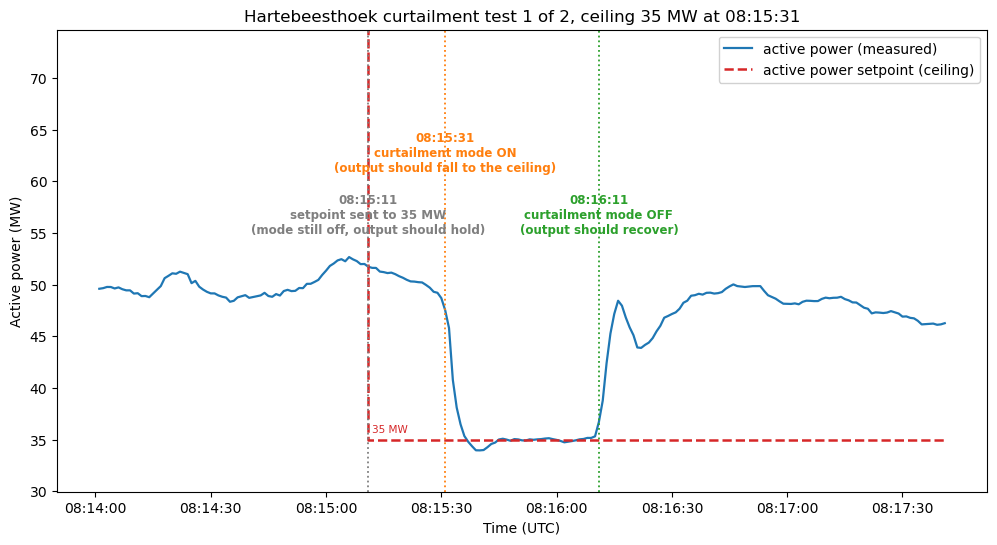


Curtailment window 2 of 2  ceiling 25 MW  figure hartebeesthoek_curtailment_084859.png
  1. Check 1: the 25 MW setpoint was sent at 08:48:43 while the mode was still off and the output kept running, so the command was received but inert.
  2. Check 2 pass: after mode ON the output settled near 25 MW, at or below the 25 MW ceiling, so the plant was curtailed to the ceiling.
  3. Check 3 pass: after mode OFF at 08:49:45 the output recovered to about 45 MW, back near its earlier 49 MW, so it returned to full output.


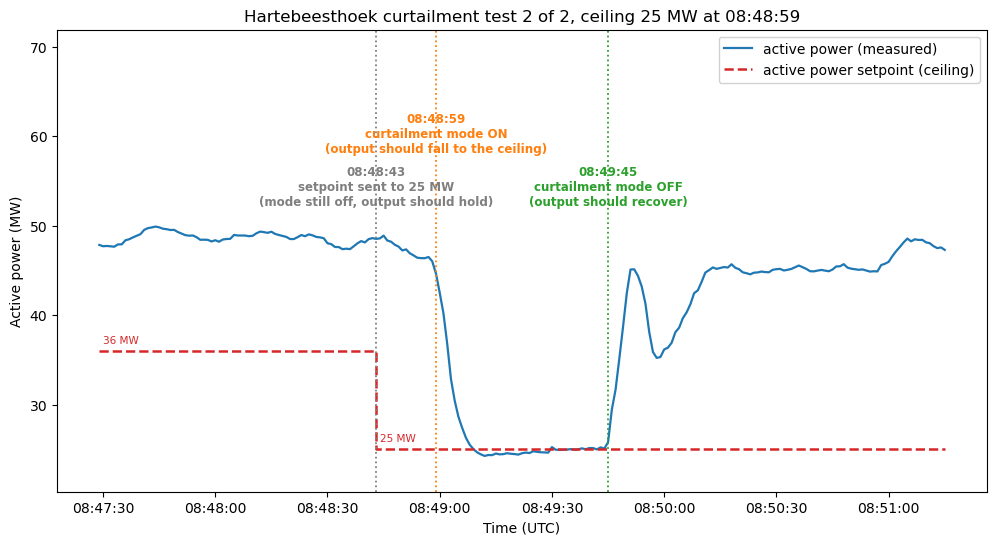

In [4]:
# =============================================================================
# CURTAILMENT TEST  (Absolute Production Constraint)
#
# What the plant must do, straight from the acceptance procedure:
#   CHECK 1  Ceiling setpoint sent while the mode is still OFF -> output should NOT
#            move yet (the command is received but inert).
#   CHECK 2  Curtailment mode ON  -> output should pull down to sit AT OR BELOW the
#            commanded ceiling.
#   CHECK 3  Curtailment mode OFF -> output should return to its earlier level.
#
# A "window" is one occurrence of the test. We find every standalone occurrence
# (curtailment mode on while the power-gradient limiter is off) and draw one graph
# and one set of findings per window. Every value is read from the data.
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. The channels this test needs, found by role (never by a fixed column name).
power_col   = resolve("poc_p", required=True)    # measured active power
setpoint_col = resolve("sp_p", required=True)    # active power setpoint (the ceiling)
curtail_col = resolve("ap_mode", required=True)  # curtailment mode on/off flag
gradient_col = resolve("pg_mode")                # power-gradient flag (used to exclude its windows)

# 2. Find every standalone curtailment window in scope (whole record unless limited).
cfg = EVENT_WINDOWS.get("curtailment")
scope = df.loc[cfg[0]:cfg[1]] if (cfg and all(cfg)) else df
windows = []
for start, end in on_segments(scope[curtail_col]):
    gradient_also_on = scope[gradient_col].astype(bool).loc[start:end].mean() if gradient_col else 0.0
    if gradient_also_on < 0.5:                    # skip windows that belong to the gradient test
        windows.append((start, end))

def plot_curtailment(mode_on, window_end, n, total):
    win      = window_around(mode_on, window_end)   # padded slice around this window
    curtail  = win[curtail_col].astype(bool)
    power    = win[power_col]                        # measured active power
    setpoint = win[setpoint_col]

    # --- Find the three procedure moments in the data ------------------------
    later_off = curtail.loc[mode_on:].index[~curtail.loc[mode_on:]]
    mode_off  = later_off[0] if len(later_off) else None     # when the mode goes off again
    sp_changes = setpoint.ne(setpoint.shift())
    sp_changes.iloc[0] = False                               # first sample is the window edge, not a change
    sent_steps = setpoint.index[sp_changes & (setpoint.index <= mode_on)]
    sp_sent   = sent_steps[-1] if len(sent_steps) else None  # the setpoint that set the ceiling
    ceiling   = setpoint.loc[mode_on]
    sent_with_mode = sp_sent is not None and abs(mode_on - sp_sent) <= pd.Timedelta(seconds=5)

    # --- The acceptance checks, computed plainly from the measured data ------
    held_output  = float(power[curtail].median())            # output while curtailment is on
    CHECK2_curtailed = held_output <= ceiling + max(1.0, 0.05 * abs(ceiling))   # at or below the ceiling?

    before_level = float(power[power.index < mode_on].median()) if (power.index < mode_on).any() else None
    after_series = power[power.index > mode_off] if mode_off is not None else power.iloc[0:0]
    after_level  = float(after_series.median()) if len(after_series) else None
    CHECK3_returned = (before_level is not None and after_level is not None
                       and after_level >= before_level - max(2.0, 0.1 * abs(before_level)))  # back to earlier level?

    # --- Draw the graph ------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(power.index, power, color="#1f77b4", lw=1.6, label="active power (measured)")
    ax.plot(setpoint.index, setpoint, color="#d62728", lw=1.8, ls="--", drawstyle="steps-post",
            label="active power setpoint (ceiling)")
    # value label on each setpoint level that is within view
    for ts, val in setpoint[setpoint.ne(setpoint.shift())].items():
        if power.min() - 5 <= val <= power.max() + 5:
            ax.annotate(f"{val:.0f} MW", xy=(ts, val), xytext=(3, 4), textcoords="offset points",
                        ha="left", va="bottom", fontsize=7.5, color="#d62728",
                        bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.6))

    # mark each moment with its time and what should happen there
    events = []
    if sent_with_mode:
        events.append((mode_on, "#ff7f0e", f"{mode_on:%H:%M:%S}\nsetpoint {ceiling:.0f} MW sent and mode ON together"))
    else:
        if sp_sent is not None:
            events.append((sp_sent, "#7f7f7f", f"{sp_sent:%H:%M:%S}\nsetpoint sent to {ceiling:.0f} MW\n(mode still off, output should hold)"))
        events.append((mode_on, "#ff7f0e", f"{mode_on:%H:%M:%S}\ncurtailment mode ON\n(output should fall to the ceiling)"))
    if mode_off is not None:
        events.append((mode_off, "#2ca02c", f"{mode_off:%H:%M:%S}\ncurtailment mode OFF\n(output should recover)"))
    mark_events(ax, events, power.max(), gap=6, fontsize=8.5)

    ax.set_ylim(power.min() - 4, power.max() + 22)
    ax.set_xlabel(f"Time ({TIME_ZONE_LABEL})")
    ax.set_ylabel("Active power (MW)")
    ax.set_title(f"{SITE_NAME} curtailment test {n} of {total}, ceiling {ceiling:.0f} MW at {mode_on:%H:%M:%S}")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.legend(loc="upper right", framealpha=0.9)
    out_path = OUTPUT_DIR / f"{SITE_SLUG}_curtailment_{mode_on:%H%M%S}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")

    # --- Findings, written straight from the checks above --------------------
    story = []
    if sent_with_mode:                                                       # CHECK 1
        story.append(f"The {ceiling:.0f} MW setpoint and the mode were switched on together at "
                     f"{mode_on:%H:%M:%S}, so there is no separate sent-but-inert phase here.")
    elif sp_sent is not None:
        story.append(f"Check 1: the {ceiling:.0f} MW setpoint was sent at {sp_sent:%H:%M:%S} while the mode "
                     f"was still off and the output kept running, so the command was received but inert.")
    else:
        story.append("The setpoint was already at its ceiling before this window, so the moment it was sent "
                     "is not captured here.")
    if CHECK2_curtailed:                                                     # CHECK 2
        story.append(f"Check 2 pass: after mode ON the output settled near {held_output:.0f} MW, at or below "
                     f"the {ceiling:.0f} MW ceiling, so the plant was curtailed to the ceiling.")
    else:
        story.append(f"Check 2 fail: after mode ON the output stayed near {held_output:.0f} MW, above the "
                     f"{ceiling:.0f} MW ceiling, so it was not curtailed to the ceiling.")
    if mode_off is None:                                                     # CHECK 3
        story.append("Curtailment mode is still on at the end of this window, so the return to full output "
                     "is not captured here.")
    elif after_level is None:
        story.append(f"Mode OFF at {mode_off:%H:%M:%S} sits at the window edge, so recovery is not captured here.")
    elif CHECK3_returned:
        story.append(f"Check 3 pass: after mode OFF at {mode_off:%H:%M:%S} the output recovered to about "
                     f"{after_level:.0f} MW, back near its earlier {before_level:.0f} MW, so it returned to full output.")
    else:
        story.append(f"Check 3 fail: after mode OFF at {mode_off:%H:%M:%S} the output recovered only to about "
                     f"{after_level:.0f} MW, below its earlier {before_level:.0f} MW, so it did not fully return.")

    print(f"\nCurtailment window {n} of {total}  ceiling {ceiling:.0f} MW  figure {out_path.name}")
    for k, line in enumerate(story, start=1):
        print(f"  {k}. {line}")
    plt.show()

# 3. One graph and one set of findings per window.
print(f"Standalone curtailment windows found: {len(windows)}")
if not windows:
    print("Curtailment mode is never on without power gradient here, so there is nothing to plot.")
for n, (start, end) in enumerate(windows, start=1):
    plot_curtailment(start, end, n, len(windows))

### What the curtailment plots show

Each standalone curtailment window tells the same three-step story, and the notebook draws one plot per window so they can be compared at a glance. Before the constraint bites, the plant runs at its operating level and the ceiling setpoint is sent while the mode is still off: the output does not move, which is the first check, the command received but inert [1]. When the mode is switched on the output falls within seconds to sit on the ceiling and holds there, respecting it as a hard maximum rather than a target to climb to. When the mode is switched off the output climbs back toward its earlier level. The printed findings under each plot carry that window's exact times, its ceiling and the recovered level, and say plainly if any phase was not captured in the data.

## Power gradient constraint test

The power gradient constraint limits how fast the plant may change its output. Instead of jumping straight to a new setpoint, the plant must move towards it at a commanded rate, measured in megawatts per minute (MW/min), with a separate limit for ramping up and ramping down. The procedure [1] sets a down rate, switches power gradient mode on, commands a lower setpoint and checks the plant descends at that rate, then sets an up rate, commands a higher setpoint and checks the plant climbs at that rate.

The cell below finds every power gradient window in the record and draws one graph per window. While the mode is engaged it measures the slope the plant follows for each setpoint change by least-squares and compares it against the commanded limit for that direction. The measured ramp is drawn as a guide line, the curtailment mode that actually drives each move is marked with its on and off times along the bottom, and the findings give the observed rate beside the commanded one, anchored to the interval it was measured over.

Power gradient windows found: 2

Power gradient window 1 of 2  figure hartebeesthoek_power_gradient_081911.png
  1. Power gradient mode was switched on at 08:19:11, so the plant should move between setpoints at the commanded rate rather than as fast as it can.
  2. At 08:19:35 the setpoint moved down to 26 MW, and from 08:20:03 to 08:20:51 the plant ramped at about 20 MW/min, close to the limit of 20 MW/min.
  3. At 08:22:06 the setpoint moved up to 36 MW, and from 08:22:11 to 08:22:51 the plant ramped at about 10 MW/min, close to the limit of 10 MW/min.
  4. Power gradient mode was released at 08:23:27.


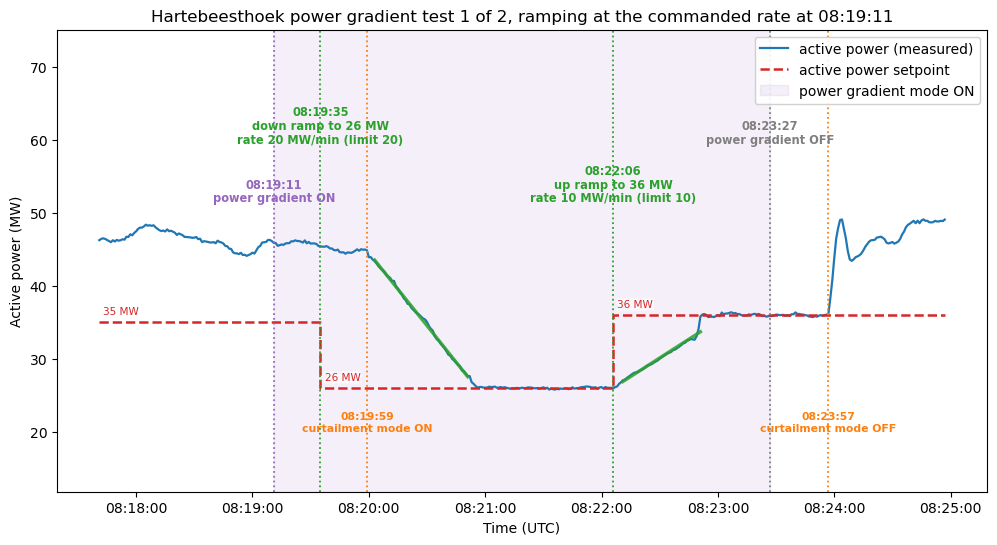


Power gradient window 2 of 2  figure hartebeesthoek_power_gradient_085141.png
  1. Power gradient mode was switched on at 08:51:41, so the plant should move between setpoints at the commanded rate rather than as fast as it can.
  2. At 08:52:15 the setpoint moved down to 39 MW, and from 08:52:29 to 08:53:21 the plant ramped at about 11 MW/min, close to the limit of 10 MW/min.
  3. At 08:54:47 the setpoint moved up to 44 MW, and from 08:54:52 to 08:55:39 the plant ramped at about 6 MW/min, close to the limit of 5 MW/min.
  4. Power gradient mode was released at 08:57:24.


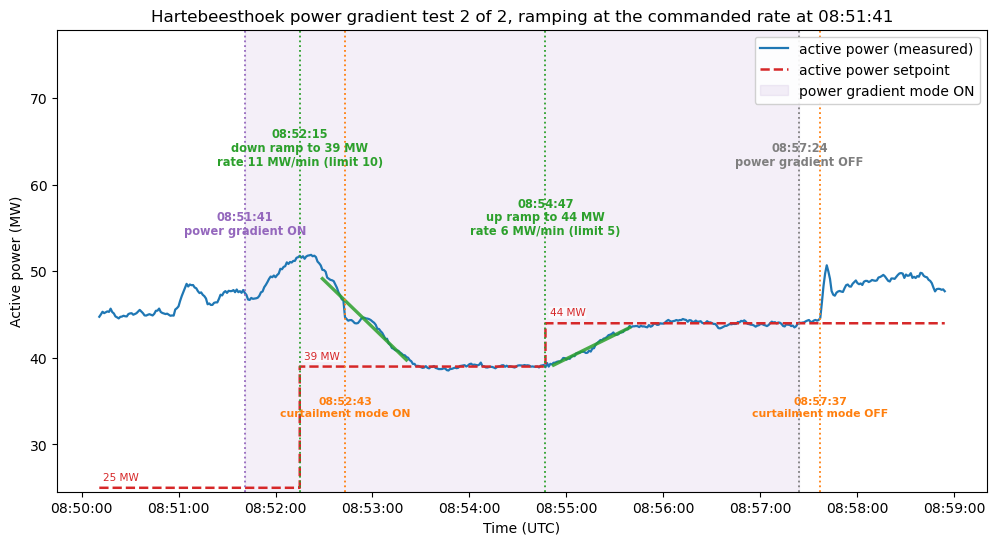

In [5]:
# =============================================================================
# POWER GRADIENT TEST  (Ramp Rate Constraint)
#
# What the plant must do, straight from the acceptance procedure:
#   With power gradient mode ON, when the active power setpoint changes the plant must
#   move to the new setpoint NO FASTER than the commanded ramp rate (MW/min). There is
#   a separate limit for ramping up and for ramping down.
#   CHECK  for each setpoint change: measured ramp rate vs the commanded limit
#          (reported as close to / faster than / slower than the limit).
#
# A "window" is one occurrence (one power-gradient-on period); one graph each. The
# curtailment mode is what physically drives the plant to each setpoint, so its on and
# off times are marked along the bottom for context.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. The channels this test needs, found by role.
power_col    = resolve("poc_p", required=True)    # measured active power
setpoint_col = resolve("sp_p", required=True)     # active power setpoint
gradient_col = resolve("pg_mode", required=True)  # power gradient mode on/off flag
curtail_col  = resolve("ap_mode")                 # curtailment flag (drives the moves)
up_limit_col   = resolve("ramp_up")               # commanded up ramp limit (MW/min)
down_limit_col = resolve("ramp_down")             # commanded down ramp limit (MW/min)

# 2. Find every power gradient window in scope (whole record unless limited).
cfg = EVENT_WINDOWS.get("power_gradient")
scope = df.loc[cfg[0]:cfg[1]] if (cfg and all(cfg)) else df
windows = on_segments(scope[gradient_col])


def measure_ramp(power_segment, start_value, target_value):
    """Measure how fast the plant actually moved, in MW per minute.

    The rate is the slope of a straight line fitted over the middle of the move, from
    10 percent risen to 90 percent risen. Using the middle skips the dead time before
    the move starts and the flattening as it arrives, so the number is the true ramp
    slope. Returns a small labelled result, or None if the move is too small to be a ramp.
    """
    total_move = target_value - start_value
    if abs(total_move) < 0.5:
        return None

    # The 10 percent and 90 percent points of the move.
    ten_percent_point = start_value + 0.1 * total_move
    ninety_percent_point = start_value + 0.9 * total_move

    # Find when the measured power first passes each point. Moving up and moving down
    # are handled separately because the comparison flips direction.
    if total_move > 0:
        passed_ten = power_segment.index[power_segment >= ten_percent_point]
        passed_ninety = power_segment.index[power_segment >= ninety_percent_point]
    else:
        passed_ten = power_segment.index[power_segment <= ten_percent_point]
        passed_ninety = power_segment.index[power_segment <= ninety_percent_point]

    # The ramp starts when it first passes 10 percent.
    if len(passed_ten) > 0:
        ramp_start = passed_ten[0]
    else:
        ramp_start = power_segment.index[0]

    # The ramp ends when it first passes 90 percent after that.
    passed_ninety = passed_ninety[passed_ninety > ramp_start]
    if len(passed_ninety) > 0:
        ramp_end = passed_ninety[0]
    else:
        ramp_end = power_segment.index[-1]

    # Fit a straight line to the power over that interval; its slope is the ramp rate.
    ramp = power_segment.loc[ramp_start:ramp_end]
    if len(ramp) < 2:
        return None
    minutes = (ramp.index - ramp.index[0]).total_seconds().to_numpy() / 60.0
    slope, intercept = np.polyfit(minutes, ramp.to_numpy(), 1)

    return {
        "rate": float(slope),                                # MW per minute
        "t_start": ramp_start,
        "p_start": float(intercept + slope * minutes[0]),    # fitted line, start point
        "t_end": ramp_end,
        "p_end": float(intercept + slope * minutes[-1]),     # fitted line, end point
    }


def find_ramps(win, gradient_on, active_until):
    """One entry per setpoint change while the mode is engaged, with its measured rate."""
    power = win[power_col]
    setpoint = win[setpoint_col]

    setpoint_changes = setpoint.ne(setpoint.shift())
    setpoint_changes.iloc[0] = False                         # first sample is the window edge
    step_times = setpoint.index[setpoint_changes]
    step_times = step_times[(step_times >= gradient_on) & (step_times <= active_until)]

    ramps = []
    for i, step_time in enumerate(step_times):
        target = setpoint.loc[step_time]
        start_value = power.loc[step_time]

        # Look at the power from this step until the next step (or the mode going off).
        if i + 1 < len(step_times):
            next_step = step_times[i + 1]
        else:
            next_step = active_until
        measured = measure_ramp(power.loc[step_time:next_step], start_value, target)
        if measured is None:
            continue

        # Which way did it move, and which commanded limit applies?
        if target < start_value:
            direction = "down"
            limit_col = down_limit_col
        else:
            direction = "up"
            limit_col = up_limit_col
        limit = win[limit_col].loc[step_time] if limit_col else None

        ramp = dict(measured)                                # copy the measured result
        ramp.update(ts=step_time, target=target, direction=direction, limit=limit)
        ramps.append(ramp)
    return ramps


def plot_power_gradient(gradient_on, window_end, n, total):
    win      = window_around(gradient_on, window_end)
    gradient = win[gradient_col].astype(bool)
    power    = win[power_col]
    setpoint = win[setpoint_col]

    # When does the mode go off again?
    still_off = gradient.loc[gradient_on:].index[~gradient.loc[gradient_on:]]
    if len(still_off) > 0:
        gradient_off = still_off[0]
    else:
        gradient_off = None
    active_until = gradient_off if gradient_off is not None else win.index[-1]

    ramps = find_ramps(win, gradient_on, active_until)

    # --- Draw the graph ------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(power.index, power, color="#1f77b4", lw=1.6, label="active power (measured)")
    ax.plot(setpoint.index, setpoint, color="#d62728", lw=1.8, ls="--", drawstyle="steps-post",
            label="active power setpoint")
    ax.axvspan(gradient_on, active_until, color="#9467bd", alpha=0.10, label="power gradient mode ON")

    # the measured slope of each ramp, drawn as a guide line
    for ramp in ramps:
        ax.plot([ramp["t_start"], ramp["t_end"]], [ramp["p_start"], ramp["p_end"]],
                color="#2ca02c", lw=2.4, alpha=0.85)

    # value label on each setpoint level
    for ts, val in setpoint[setpoint.ne(setpoint.shift())].items():
        ax.annotate(f"{val:.0f} MW", xy=(ts, val), xytext=(3, 4), textcoords="offset points",
                    ha="left", va="bottom", fontsize=7.5, color="#d62728",
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.6))

    # top markers: mode on/off and each ramp; the label reads "rate X (limit Y)"
    top_events = [(gradient_on, "#9467bd", f"{gradient_on:%H:%M:%S}\npower gradient ON")]
    for ramp in ramps:
        if ramp["limit"] is not None:
            limit_txt = f"{ramp['limit']:.0f}"
        else:
            limit_txt = "n/a"
        top_events.append((ramp["ts"], "#2ca02c",
                           f"{ramp['ts']:%H:%M:%S}\n{ramp['direction']} ramp to {ramp['target']:.0f} MW\n"
                           f"rate {abs(ramp['rate']):.0f} MW/min (limit {limit_txt})"))
    if gradient_off is not None:
        top_events.append((gradient_off, "#7f7f7f", f"{gradient_off:%H:%M:%S}\npower gradient OFF"))
    mark_events(ax, top_events, power.max(), gap=8, fontsize=8.2)

    # bottom markers: curtailment mode on and off, with their times
    if curtail_col:
        for mode_start, mode_end in on_segments(win[curtail_col]):
            for ts, text in ((mode_start, "curtailment mode ON"), (mode_end, "curtailment mode OFF")):
                ax.axvline(ts, color="#ff7f0e", ls=":", lw=1.3)
                ax.annotate(f"{ts:%H:%M:%S}\n{text}", xy=(ts, power.min()), xytext=(ts, power.min() - 3),
                            ha="center", va="top", fontsize=7.8, color="#ff7f0e", fontweight="bold")

    ax.set_ylim(power.min() - 14, power.max() + 26)
    ax.set_xlabel(f"Time ({TIME_ZONE_LABEL})")
    ax.set_ylabel("Active power (MW)")
    ax.set_title(f"{SITE_NAME} power gradient test {n} of {total}, ramping at the commanded rate at {gradient_on:%H:%M:%S}")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.legend(loc="upper right", framealpha=0.9)
    out_path = OUTPUT_DIR / f"{SITE_SLUG}_power_gradient_{gradient_on:%H%M%S}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")

    # --- Findings: one line per ramp comparing measured rate to the limit ----
    story = [f"Power gradient mode was switched on at {gradient_on:%H:%M:%S}, so the plant should move "
             "between setpoints at the commanded rate rather than as fast as it can."]
    for ramp in ramps:
        rate_txt = f"{abs(ramp['rate']):.0f} MW/min"
        interval = f"from {ramp['t_start']:%H:%M:%S} to {ramp['t_end']:%H:%M:%S}"
        if ramp["limit"] is None:
            story.append(f"At {ramp['ts']:%H:%M:%S} the setpoint moved {ramp['direction']} to {ramp['target']:.0f} MW, "
                         f"and {interval} the plant ramped at about {rate_txt}; no rate limit was recorded.")
            continue
        # CHECK: how the measured rate compares to the commanded limit
        gap = abs(ramp["rate"]) - ramp["limit"]
        if abs(gap) <= 0.2 * ramp["limit"]:
            verdict = "close to the limit"
        elif gap > 0:
            verdict = "faster than the limit"
        else:
            verdict = "slower than the limit"
        story.append(f"At {ramp['ts']:%H:%M:%S} the setpoint moved {ramp['direction']} to {ramp['target']:.0f} MW, "
                     f"and {interval} the plant ramped at about {rate_txt}, {verdict} of {ramp['limit']:.0f} MW/min.")
    if not ramps:
        story.append("No setpoint change happens while power gradient is on, so the rate limit is not "
                     "exercised in this window.")
    if gradient_off is not None:
        story.append(f"Power gradient mode was released at {gradient_off:%H:%M:%S}.")
    else:
        story.append("Power gradient mode is still on at the end of this window.")

    print(f"\nPower gradient window {n} of {total}  figure {out_path.name}")
    for k, line in enumerate(story, start=1):
        print(f"  {k}. {line}")
    plt.show()


# 3. One graph and one set of findings per window.
print(f"Power gradient windows found: {len(windows)}")
if not windows:
    print("Power gradient mode is never on here, so there is nothing to plot.")
for n, (start, end) in enumerate(windows, start=1):
    plot_power_gradient(start, end, n, len(windows))

## Frequency response

The grid runs as one synchronised machine, and its **frequency** is how fast that machine turns, measured in **hertz (Hz, cycles per second)**. The South African grid is built around a nominal 50 Hz. Frequency rises when more power is generated than is being used and falls when more is used than generated, so holding it near 50 Hz means constantly balancing supply against demand across the whole **national grid (the National Integrated Power System, NIPS)**.

When the frequency climbs too high there is too much generation on the system, and generators are asked to back off. A **renewable power plant (RPP)** like this one must take part in that correction above a set frequency. The behaviour is described by two settings. The **deadband** is a band around 50 Hz inside which the plant does nothing, so the normal small wobbles are ignored. The **droop** is the steepness of the response once the deadband is passed: the South African Grid Code defines droop as the percentage frequency change needed to move the plant all the way from no-load to rated output, so a smaller droop means a sharper cut in power for the same rise in frequency. This high-frequency case, where the plant must reduce its output, is the **over-frequency** response.

Everything is judged at the **point of connection (POC)**, the single metering point where the plant joins the grid. The test is commanded and supervised by the **System Operator (SO)**, the body that runs the grid.

This section checks the same over-frequency test two ways. First against the acceptance procedure in the test record [1], which asks for the response to be switched on, the plant observed reacting to frequency deviations outside the deadband, then switched off. Second against the South African Grid Code requirements for renewable power plants [2], which set the exact curve the power reduction must follow above 50.5 Hz and the trip that must happen above 51.5 Hz. One note before the graphs: this logger has no separate frequency-mode on or off flag, unlike the other tests, so the over-frequency test is found directly from the swept control frequency that was injected to drive it.

### Checked against the test record procedure

The acceptance procedure [1] for frequency response is short: switch the response on, confirm the control was sent and the mode changed to on, observe the plant reacting to frequency deviations outside the deadband, then switch the response off. This logger carries no frequency-mode flag, so rather than a mode switching on and off, the test is read from the controlling frequency that was swept upward to provoke the plant. The cells below read the basic facts first, then find each over-frequency window in the record, draw one time plot per window, and report the findings.

In [6]:
# =============================================================================
# FREQUENCY RESPONSE  -  reading the test off the data (basic facts)
#
# This sheet has no frequency mode on/off flag, so before anything else we read the
# plain facts that tell us how the over-frequency test was driven and measured:
#   - the controlling frequency that was swept upward to provoke a response
#   - the recorded droop setting (read from the sheet, never assumed)
#   - the measured grid frequency at the point of connection
#   - a check that no frequency mode flag exists in this record
# =============================================================================

# 1. The channels this test needs, found by role (never by a fixed column name).
control_freq_col = resolve("f_control", required=True)  # injected control frequency (the stimulus)
grid_freq_col    = resolve("grid_freq", required=True)   # measured grid frequency at the POC
power_col        = resolve("poc_p", required=True)       # measured active power at the POC
droop_col        = resolve("droop_f")                    # recorded frequency droop setting (percent)

# 2. The swept controlling frequency: the signal that was driven up to provoke a response.
control_freq = df[control_freq_col].dropna()
print(f"Controlling frequency swept from {control_freq.min():.2f} Hz to {control_freq.max():.2f} Hz")

# 3. The recorded droop, read straight from the sheet (a single setting in this record).
if droop_col is not None:
    droop_levels = df[droop_col].dropna().unique()
    if len(droop_levels) == 1:
        droop_percent = float(droop_levels[0])
        print(f"Recorded frequency droop: {droop_percent:.0f} percent (read from the sheet)")
    else:
        droop_percent = float(df[droop_col].dropna().median())
        print(f"Recorded frequency droop varies; using the median {droop_percent:.1f} percent")
else:
    droop_percent = None
    print("No droop column found in this record")

# 4. The measured grid frequency, to compare against the swept control signal later.
grid_freq = df[grid_freq_col].dropna()
print(f"Measured grid frequency ranged {grid_freq.min():.2f} Hz to {grid_freq.max():.2f} Hz")
print(f"Over-frequency point used for the checks: {F4_OVER_FREQUENCY_HZ:.1f} Hz")

# 5. Is there a frequency mode on/off flag? List any mode flag whose name mentions frequency.
frequency_flags = [flag for flag in mode_cols if "freq" in _norm(flag)]
if frequency_flags:
    print(f"Frequency mode flag(s) present: {frequency_flags}")
else:
    print("No frequency mode flag exists in this record, so the test is found from the "
          "swept controlling frequency itself.")


Controlling frequency swept from 49.84 Hz to 51.90 Hz
Recorded frequency droop: 4 percent (read from the sheet)
Measured grid frequency ranged 49.82 Hz to 50.21 Hz
Over-frequency point used for the checks: 50.5 Hz
No frequency mode flag exists in this record, so the test is found from the swept controlling frequency itself.


In [7]:
# =============================================================================
# FREQUENCY RESPONSE  -  finding the over-frequency windows
#
# A "window" is one occurrence of the test: one stretch where the controlling
# frequency sat at or above the over-frequency point, meaning the stimulus was
# applied. We keep only the clean windows: those with NO active-power constraint mode
# on (curtailment, power gradient or p-Delta), so that any power reduction we later
# see is attributable to frequency alone and not to another test running at the same
# time.
#
# For each clean window we measure, straight from the data:
#   - when the frequency crossed up through the over-frequency point, and back down
#   - the peak frequency reached, and when
#   - the reference power: the output just before the crossing (the reduction is
#     measured against this)
#   - the floor power: the lowest output held during the window
#   - when the output recovered back towards its reference
# =============================================================================

# 1. The modes that constrain active power; a window overlapping any of these is not
#    a clean frequency test and is set aside.
active_power_flag   = resolve("ap_mode")     # curtailment (absolute production constraint)
power_gradient_flag = resolve("pg_mode")     # power gradient (ramp rate limit)
delta_flags = [flag for flag in mode_cols if "delta" in _norm(flag)]   # p-Delta constraint
constraint_flags = [f for f in [active_power_flag, power_gradient_flag] if f] + delta_flags

# 2. Restrict to the configured scope (whole record unless limited in the config cell).
freq_scope = EVENT_WINDOWS.get("frequency")
scope = df.loc[freq_scope[0]:freq_scope[1]] if (freq_scope and all(freq_scope)) else df

# 3. Every stretch where the controlling frequency is at or above the over-frequency point.
above_threshold = scope[control_freq_col] >= F4_OVER_FREQUENCY_HZ
raw_crossings = on_segments(above_threshold)


def measure_reference_power(power, cross_up):
    """The output just before the frequency crossed the threshold.

    Uses the median of the half minute before the crossing so a single noisy sample
    cannot set the reference. Falls back to the value at the crossing if nothing
    earlier is captured.
    """
    before = power.loc[cross_up - pd.Timedelta("30s"):cross_up]
    before = before[before.index < cross_up]
    if len(before):
        return float(before.median())
    return float(power.loc[cross_up])


def find_recovery(power, cross_down, reference_power):
    """When the output first climbed back to within reach of its reference after the
    window, or None if it did not recover before the data ran out.
    """
    after = power.loc[cross_down:]
    after = after[after.index > cross_down]
    recovered = after.index[after >= 0.9 * reference_power]
    return recovered[0] if len(recovered) else None


# 4. Keep the clean windows and measure each one.
frequency_windows = []
for cross_up, cross_down in raw_crossings:
    overlaps_constraint = False
    for flag in constraint_flags:
        if scope[flag].astype(bool).loc[cross_up:cross_down].mean() >= 0.5:
            overlaps_constraint = True
    if overlaps_constraint:
        continue

    control_segment = scope[control_freq_col].loc[cross_up:cross_down]
    power_segment = df[power_col].loc[cross_up:cross_down]
    reference_power = measure_reference_power(df[power_col], cross_up)
    floor_power = float(power_segment.min())

    frequency_windows.append({
        "cross_up": cross_up,
        "cross_down": cross_down,
        "peak_freq": float(control_segment.max()),
        "peak_time": control_segment.idxmax(),
        "reference_power": reference_power,
        "floor_power": floor_power,
        "recovery_time": find_recovery(df[power_col], cross_down, reference_power),
    })

# 5. Report what was found, honestly.
print(f"Stretches above {F4_OVER_FREQUENCY_HZ:.1f} Hz: {len(raw_crossings)}; "
      f"clean over-frequency windows (no constraint mode on): {len(frequency_windows)}")
for n, window in enumerate(frequency_windows, start=1):
    floor_percent = 100.0 * window["floor_power"] / window["reference_power"] if window["reference_power"] else float("nan")
    print(f"  Window {n}: {window['cross_up']:%H:%M:%S} to {window['cross_down']:%H:%M:%S}, "
          f"peak {window['peak_freq']:.2f} Hz, reference {window['reference_power']:.0f} MW, "
          f"floor {window['floor_power']:.0f} MW ({floor_percent:.0f} percent of reference)")
if not frequency_windows:
    print("No clean over-frequency window is present, so there is nothing to plot.")


Stretches above 50.5 Hz: 2; clean over-frequency windows (no constraint mode on): 2
  Window 1: 08:32:52 to 08:37:26, peak 51.90 Hz, reference 52 MW, floor 14 MW (26 percent of reference)
  Window 2: 09:04:35 to 09:07:37, peak 51.90 Hz, reference 48 MW, floor 13 MW (28 percent of reference)


Frequency response window 1 of 2  figure hartebeesthoek_frequency_response_083252.png


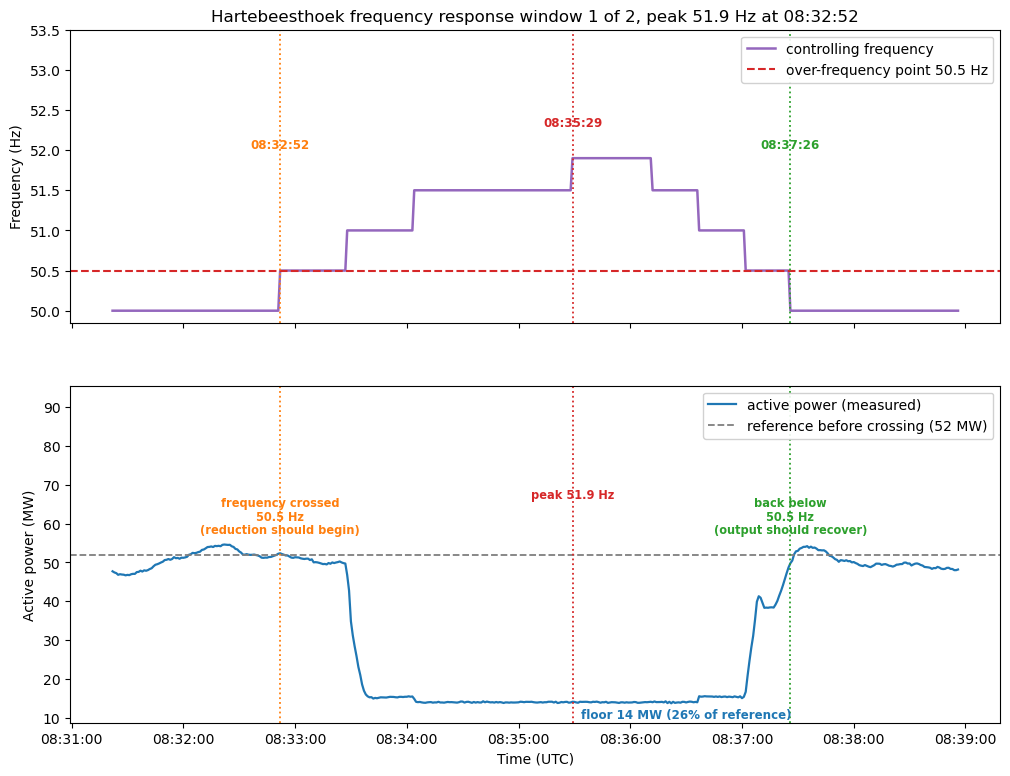

Frequency response window 2 of 2  figure hartebeesthoek_frequency_response_090435.png


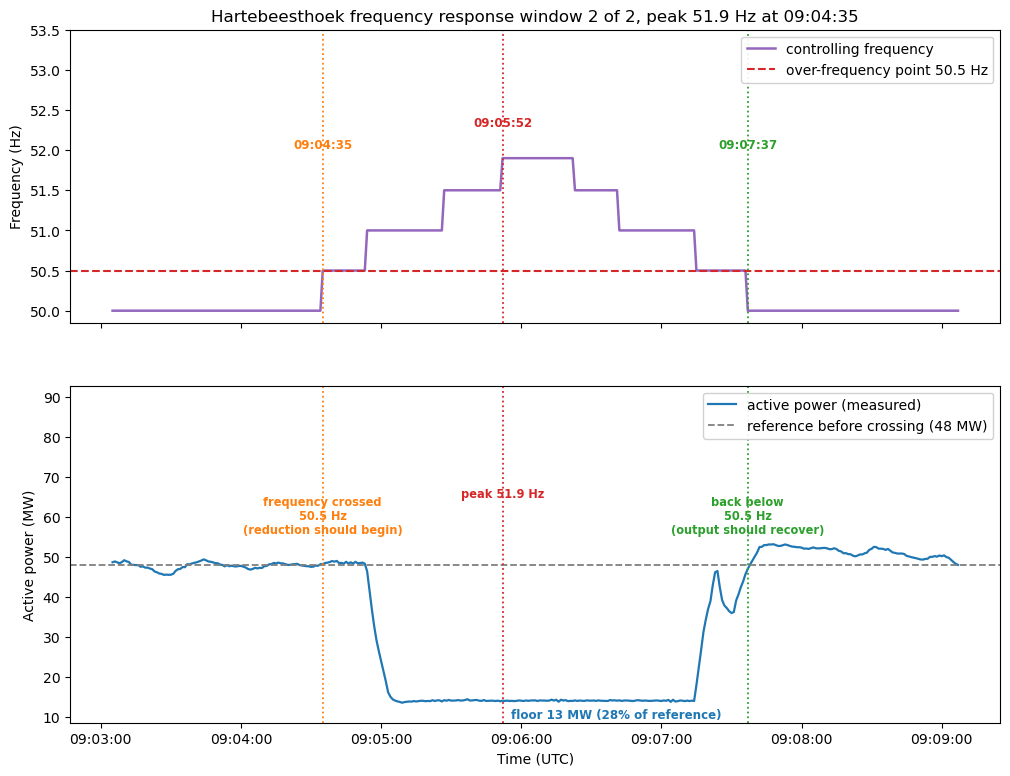

In [8]:
# =============================================================================
# FREQUENCY RESPONSE  -  one time plot per over-frequency window
#
# For each window found above we draw two stacked panels that share a time axis:
#   TOP    the controlling frequency, with the over-frequency point marked as a
#          horizontal line; each key moment is a dotted line carrying its time.
#   BOTTOM the measured active power, with the reference level it should be judged
#          against, and the same key moments marked with their times and what should
#          happen there.
# The reader should be able to see the power fall as the frequency rises past the
# threshold and recover as it drops back, all on the graph itself.
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_frequency_window(window, n, total):
    win = window_around(window["cross_up"], window["cross_down"])   # padded slice for context
    control = win[control_freq_col]
    power = win[power_col]
    reference_power = window["reference_power"]

    # --- The key moments to mark on both panels ------------------------------
    # Recovery is only shown separately when it is clearly later than the drop back
    # below the threshold; when the two nearly coincide they are the same moment and
    # one marker keeps the graph readable.
    moments = [
        (window["cross_up"], "#ff7f0e", "frequency crossed\n"
         f"{F4_OVER_FREQUENCY_HZ:.1f} Hz\n(reduction should begin)"),
        (window["peak_time"], "#d62728", f"peak {window['peak_freq']:.1f} Hz"),
        (window["cross_down"], "#2ca02c", f"back below\n{F4_OVER_FREQUENCY_HZ:.1f} Hz\n(output should recover)"),
    ]
    recovery = window["recovery_time"]
    if recovery is not None and (recovery - window["cross_down"]) > pd.Timedelta("10s"):
        moments.append((recovery, "#1f77b4", "output recovered"))

    # --- Draw the two panels -------------------------------------------------
    fig, (ax_freq, ax_power) = plt.subplots(2, 1, sharex=True, figsize=(12, 9),
                                            gridspec_kw={"height_ratios": [1, 1.15]})

    # Top panel: controlling frequency and the over-frequency point.
    ax_freq.plot(control.index, control, color="#9467bd", lw=1.8, label="controlling frequency")
    ax_freq.axhline(F4_OVER_FREQUENCY_HZ, color="#d62728", ls="--", lw=1.5,
                    label=f"over-frequency point {F4_OVER_FREQUENCY_HZ:.1f} Hz")
    # each moment is a dotted line with its time written flat above the line; every
    # second time is lifted a little further so neighbouring times never merge.
    for i, (ts, colour, _text) in enumerate(moments):
        ax_freq.axvline(ts, color=colour, ls=":", lw=1.3)
        lift_points = 5 + (i % 2) * 16
        ax_freq.annotate(f"{ts:%H:%M:%S}", xy=(ts, control.max()), xytext=(0, lift_points),
                         textcoords="offset points", ha="center", va="bottom",
                         fontsize=8.5, color=colour, fontweight="bold")
    ax_freq.set_ylim(control.min() - 0.15, control.max() + 1.6)
    ax_freq.set_ylabel("Frequency (Hz)")
    ax_freq.set_title(f"{SITE_NAME} frequency response window {n} of {total}, "
                      f"peak {window['peak_freq']:.1f} Hz at {window['cross_up']:%H:%M:%S}")
    ax_freq.legend(loc="upper right", framealpha=0.9)

    # Bottom panel: measured active power and its reference level.
    ax_power.plot(power.index, power, color="#1f77b4", lw=1.6, label="active power (measured)")
    ax_power.axhline(reference_power, color="#7f7f7f", ls="--", lw=1.3,
                     label=f"reference before crossing ({reference_power:.0f} MW)")
    floor_percent = 100.0 * window["floor_power"] / reference_power if reference_power else float("nan")
    ax_power.annotate(f"floor {window['floor_power']:.0f} MW ({floor_percent:.0f}% of reference)",
                      xy=(window["peak_time"], window["floor_power"]), xytext=(6, -4),
                      textcoords="offset points", ha="left", va="top", fontsize=8.5,
                      color="#1f77b4", fontweight="bold")
    mark_events(ax_power, moments, power.max(), gap=9, fontsize=8.2)
    # generous headroom so the legend and the lifted labels sit clear of the traces
    power_span = power.max() - power.min()
    ax_power.set_ylim(power.min() - 5, power.max() + max(38, power_span))
    ax_power.set_ylabel("Active power (MW)")
    ax_power.set_xlabel(f"Time ({TIME_ZONE_LABEL})")
    ax_power.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax_power.legend(loc="upper right", framealpha=0.9)

    out_path = OUTPUT_DIR / f"{SITE_SLUG}_frequency_response_{window['cross_up']:%H%M%S}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Frequency response window {n} of {total}  figure {out_path.name}")
    plt.show()


# One graph per window.
if not frequency_windows:
    print("No clean over-frequency window is present, so there is nothing to plot.")
for n, window in enumerate(frequency_windows, start=1):
    plot_frequency_window(window, n, len(frequency_windows))


### What the time plots show

Both windows tell the same story. While the controlling frequency sits at 50 Hz the plant runs near its reference output, about 52 MW in the first window and 48 MW in the second. The instant the frequency is stepped up through the 50.5 Hz over-frequency point the active power drops hard, and within seconds it reaches a floor of about 14 MW, close to a quarter of where it started. It holds there for as long as the frequency stays elevated, through the climb to the 51.9 Hz peak and back down, then it returns to its reference the moment the frequency drops below 50.5 Hz.

So the test record checks are clearly met in both windows: the stimulus was applied and the plant responded, in the right direction, every time. Two things are worth carrying into the grid-code comparison that follows. First, the reduction is a single sharp step down to a floor rather than a gentle slope, and that shape is what the required droop curve will be weighed against. Second, the frequency that drove all of this is the injected control frequency, not the measured grid frequency, which never left its normal band near 50 Hz, so the response was exercised by the test signal exactly as a commissioning test should.

In [9]:
# =============================================================================
# FREQUENCY RESPONSE  -  findings against the test record procedure
#
# The acceptance procedure asks two plain things of this test [1]:
#   CHECK 1  Was the stimulus applied? The controlling frequency must be driven above
#            the over-frequency point so the plant has something to react to.
#   CHECK 2  Did the plant respond? Active power must fall while the frequency is above
#            the point, and return when it drops back below.
# These are the test-record checks only. Whether the SIZE of the reduction matches the
# grid code curve is judged in the next subsection.
# =============================================================================

if not frequency_windows:
    print("No over-frequency window was captured, so the frequency response test is not "
          "exercised in this record.")

for n, window in enumerate(frequency_windows, start=1):
    reference = window["reference_power"]
    floor = window["floor_power"]
    floor_percent = 100.0 * floor / reference if reference else float("nan")
    reduction = reference - floor

    # CHECK 1: was the stimulus applied?
    stimulus_applied = window["peak_freq"] >= F4_OVER_FREQUENCY_HZ
    # CHECK 2: did the plant respond? (a clear drop in output while the frequency was high)
    plant_responded = reduction > max(2.0, 0.1 * reference)
    output_recovered = window["recovery_time"] is not None

    print(f"\nWindow {n}  {window['cross_up']:%H:%M:%S} to {window['cross_down']:%H:%M:%S}")
    if stimulus_applied:
        print(f"  1. Stimulus applied: the controlling frequency was driven to {window['peak_freq']:.1f} Hz, "
              f"above the {F4_OVER_FREQUENCY_HZ:.1f} Hz over-frequency point.")
    else:
        print(f"  1. Stimulus not applied: the controlling frequency only reached {window['peak_freq']:.1f} Hz, "
              f"not above the {F4_OVER_FREQUENCY_HZ:.1f} Hz point.")
    if plant_responded:
        print(f"  2. Plant responded: active power fell from about {reference:.0f} MW to a floor of "
              f"{floor:.0f} MW ({floor_percent:.0f} percent of reference) while the frequency was high.")
    else:
        print(f"  2. No clear response: active power stayed near {reference:.0f} MW while the frequency was high.")
    if output_recovered:
        print(f"  3. Output recovered to its reference at {window['recovery_time']:%H:%M:%S}, after the "
              "frequency dropped back below the point.")
    else:
        print("  3. The recovery is not captured before the data ends in this window.")

# Honest note about what actually drove the test.
if frequency_windows:
    print(f"\nMeasured grid frequency over the whole record stayed between {grid_freq.min():.2f} Hz and "
          f"{grid_freq.max():.2f} Hz, never above the {F4_OVER_FREQUENCY_HZ:.1f} Hz point, so this response "
          "was exercised by the injected control signal, exactly as a commissioning test should be.")



Window 1  08:32:52 to 08:37:26
  1. Stimulus applied: the controlling frequency was driven to 51.9 Hz, above the 50.5 Hz over-frequency point.
  2. Plant responded: active power fell from about 52 MW to a floor of 14 MW (26 percent of reference) while the frequency was high.
  3. Output recovered to its reference at 08:37:27, after the frequency dropped back below the point.

Window 2  09:04:35 to 09:07:37
  1. Stimulus applied: the controlling frequency was driven to 51.9 Hz, above the 50.5 Hz over-frequency point.
  2. Plant responded: active power fell from about 48 MW to a floor of 13 MW (28 percent of reference) while the frequency was high.
  3. Output recovered to its reference at 09:07:38, after the frequency dropped back below the point.

Measured grid frequency over the whole record stayed between 49.82 Hz and 50.21 Hz, never above the 50.5 Hz point, so this response was exercised by the injected control signal, exactly as a commissioning test should be.


### Checked against the South African Grid Code

The grid code requirements for renewable power plants [2] are more specific than the test record. Above the over-frequency point at 50.5 Hz the plant must reduce its active power along a straight line set by its droop, drawn as Figure 6 in the code. A droop of D percent means the output should fall all the way to zero over a frequency rise of D percent of the nominal frequency, so a smaller droop is a steeper cut. The plant must also trip if the frequency stays above 51.5 Hz for longer than four seconds. The cells below redraw each window against that required curve, measure how closely the reduction follows it, check the trip rule, and gather the grid-code verdict.

Figure 6 comparison window 1 of 2  figure hartebeesthoek_frequency_figure6_083252.png


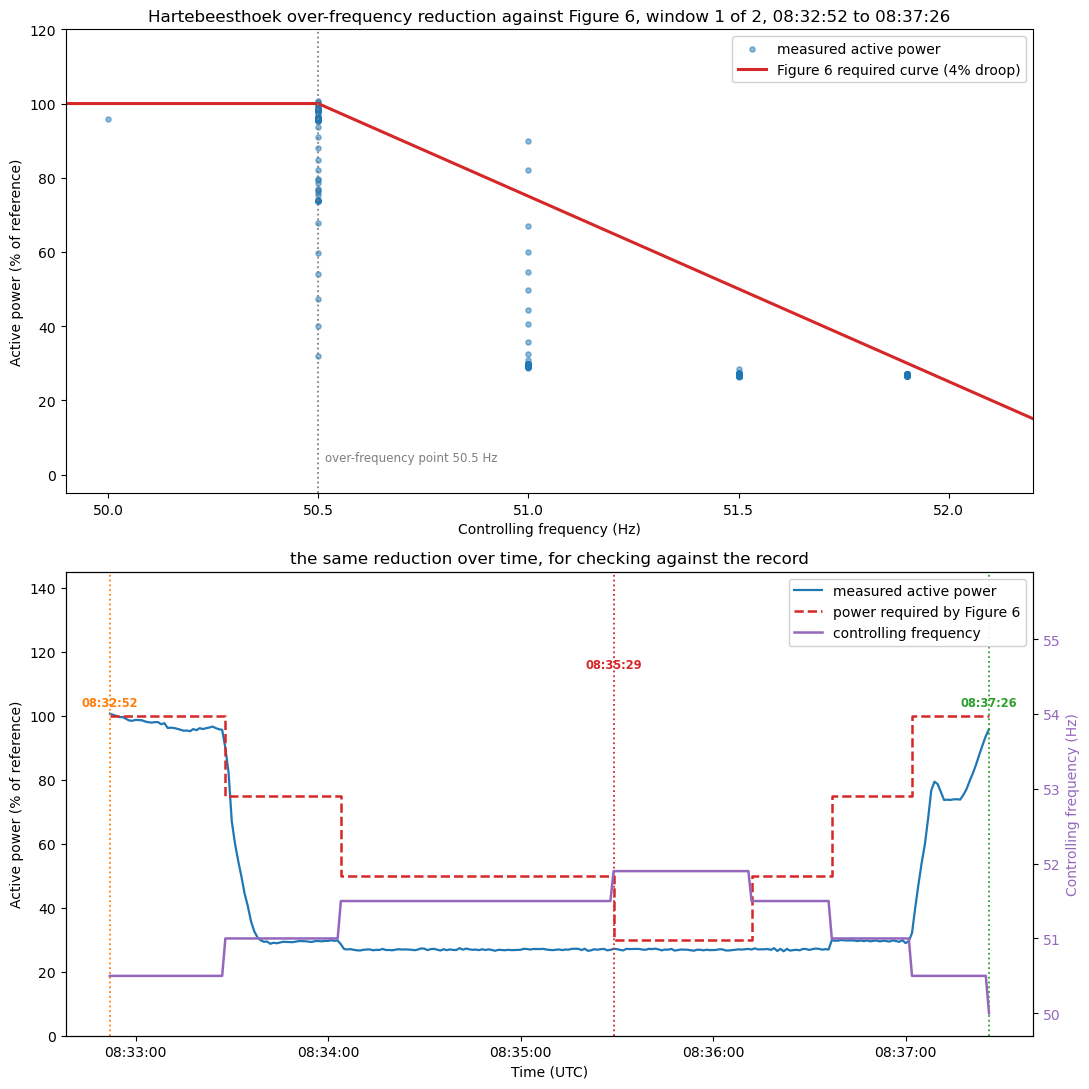

Figure 6 comparison window 2 of 2  figure hartebeesthoek_frequency_figure6_090435.png


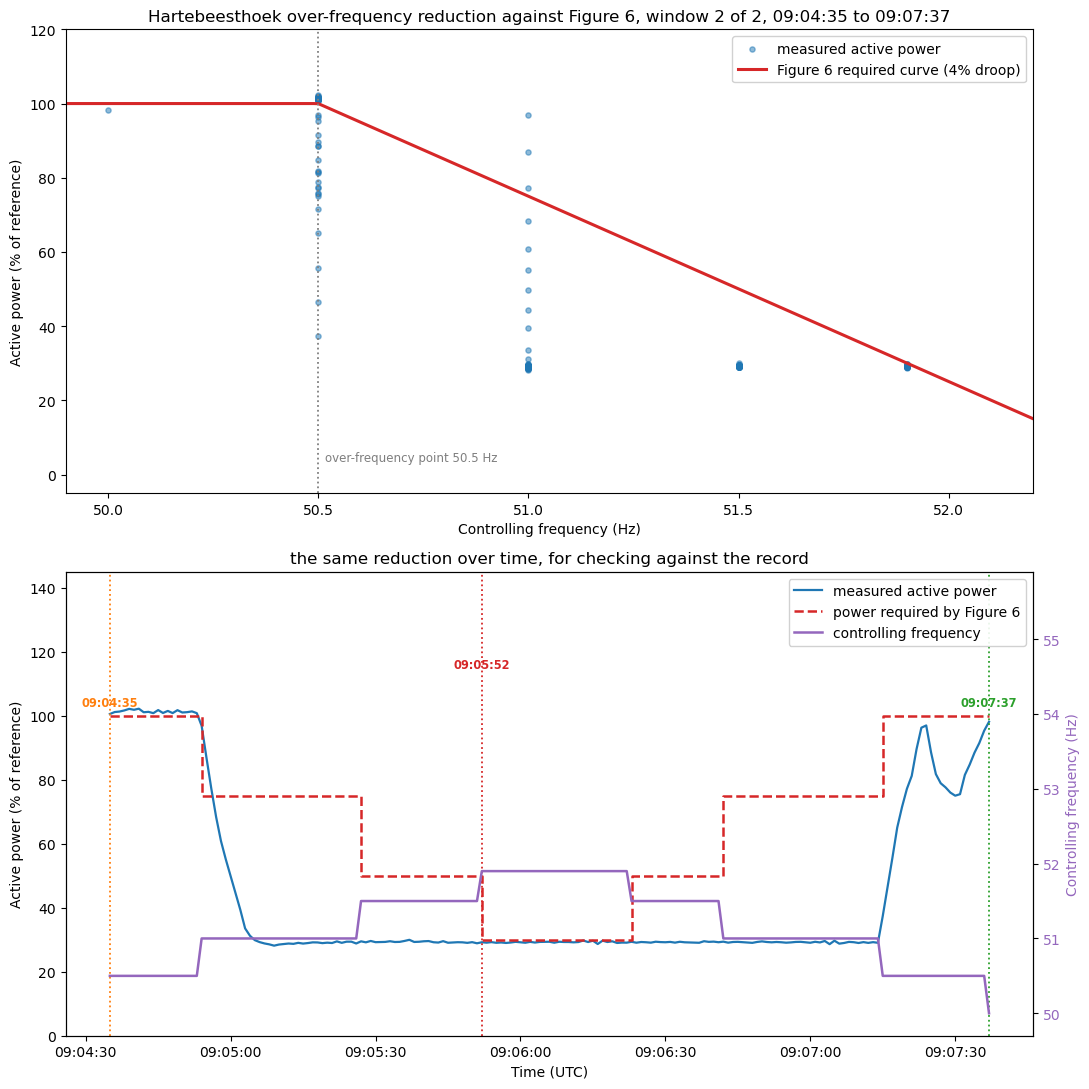

In [10]:
# =============================================================================
# FREQUENCY RESPONSE  -  the required Figure 6 curve and what the plant actually did
#
# The grid code Figure 6 [2] sets the shape of the over-frequency reduction:
#   - at or below the over-frequency point the plant may run at full output (100%)
#   - above it the plant must reduce active power along a straight line whose steepness
#     is set by the droop; a droop of D percent takes the output from full to zero over
#     a frequency rise of D percent of the nominal frequency
# Each window is shown two ways that share the same y axis (active power as a percent of
# the pre-threshold reference):
#   TOP    the shape, against frequency, with the required Figure 6 curve laid on top
#   BOTTOM the same percentages against the clock, the measured reduction and what the
#          curve required at each instant, so any point can be checked against the record
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def required_power_percent(frequency, droop, f4, f_nominal):
    """The active power the Figure 6 curve allows, as a percent of the reference.

    At or below the over-frequency point f4 the full 100 percent is allowed. Above it
    the allowance falls along a straight line; a droop of `droop` percent uses up the
    whole 100 percent over a frequency rise of (droop / 100 * f_nominal) hertz. The
    result is held between 0 and 100 percent.
    """
    full_swing_hz = (droop / 100.0) * f_nominal
    if full_swing_hz <= 0:
        return np.where(frequency > f4, 0.0, 100.0)
    allowed = 100.0 - (frequency - f4) / full_swing_hz * 100.0
    allowed = np.clip(allowed, 0.0, 100.0)
    return np.where(frequency <= f4, 100.0, allowed)


# Nominal frequency is read from the measured grid frequency (close to 50 Hz here).
nominal_freq = float(grid_freq.median())


def plot_figure6_window(window, n, total):
    control = scope[control_freq_col].loc[window["cross_up"]:window["cross_down"]]
    power = df[power_col].loc[window["cross_up"]:window["cross_down"]]
    reference_power = window["reference_power"]
    measured_percent = 100.0 * power / reference_power
    required_over_time = required_power_percent(control.values, droop_percent,
                                               F4_OVER_FREQUENCY_HZ, nominal_freq)

    fig, (ax_shape, ax_time) = plt.subplots(2, 1, figsize=(11, 11))

    # --- Top: the shape against frequency, with the required curve --------------
    freq_axis = np.linspace(F4_OVER_FREQUENCY_HZ - 0.6, control.max() + 0.3, 200)
    required_curve = required_power_percent(freq_axis, droop_percent, F4_OVER_FREQUENCY_HZ, nominal_freq)
    ax_shape.scatter(control.values, measured_percent.values, s=14, color="#1f77b4", alpha=0.5,
                     label="measured active power")
    ax_shape.plot(freq_axis, required_curve, color="#d62728", lw=2.2,
                  label=f"Figure 6 required curve ({droop_percent:.0f}% droop)")
    ax_shape.axvline(F4_OVER_FREQUENCY_HZ, color="#7f7f7f", ls=":", lw=1.3)
    ax_shape.annotate(f"over-frequency point {F4_OVER_FREQUENCY_HZ:.1f} Hz",
                      xy=(F4_OVER_FREQUENCY_HZ, 3), xytext=(5, 0), textcoords="offset points",
                      ha="left", va="bottom", fontsize=8.5, color="#7f7f7f")
    ax_shape.set_ylim(-5, 120)
    ax_shape.set_xlim(F4_OVER_FREQUENCY_HZ - 0.6, control.max() + 0.3)
    ax_shape.set_xlabel("Controlling frequency (Hz)")
    ax_shape.set_ylabel("Active power (% of reference)")
    ax_shape.set_title(f"{SITE_NAME} over-frequency reduction against Figure 6, window {n} of {total}, "
                       f"{window['cross_up']:%H:%M:%S} to {window['cross_down']:%H:%M:%S}")
    ax_shape.legend(loc="upper right", framealpha=0.9)

    # --- Bottom: the same percentages against the clock ------------------------
    # left axis: the power as a percent of reference (measured and what was required);
    # right axis: the controlling frequency that drove it, so stimulus and response sit
    # on one timeline.
    ax_time.plot(power.index, measured_percent.values, color="#1f77b4", lw=1.6,
                 label="measured active power")
    ax_time.plot(control.index, required_over_time, color="#d62728", lw=1.8, ls="--",
                 drawstyle="steps-post", label="power required by Figure 6")
    ax_time.set_ylim(0, 145)
    ax_time.set_ylabel("Active power (% of reference)")
    ax_time.set_xlabel(f"Time ({TIME_ZONE_LABEL})")
    ax_time.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax_time.set_title("the same reduction over time, for checking against the record")

    ax_freq_axis = ax_time.twinx()
    ax_freq_axis.plot(control.index, control.values, color="#9467bd", lw=1.8,
                      label="controlling frequency")
    ax_freq_axis.set_ylabel("Controlling frequency (Hz)", color="#9467bd")
    ax_freq_axis.tick_params(axis="y", labelcolor="#9467bd")
    # keep the frequency trace low in the panel so it stays clear of the power lines
    ax_freq_axis.set_ylim(control.min() - 0.3, control.max() + 4.0)

    moments = [
        (window["cross_up"], "#ff7f0e", f"{window['cross_up']:%H:%M:%S}"),
        (window["peak_time"], "#d62728", f"{window['peak_time']:%H:%M:%S}"),
        (window["cross_down"], "#2ca02c", f"{window['cross_down']:%H:%M:%S}"),
    ]
    mark_events(ax_time, moments, 100.0, gap=12, fontsize=8.2)

    # one combined legend covering both axes
    handles_left, labels_left = ax_time.get_legend_handles_labels()
    handles_right, labels_right = ax_freq_axis.get_legend_handles_labels()
    ax_time.legend(handles_left + handles_right, labels_left + labels_right,
                   loc="upper right", framealpha=0.9)

    fig.tight_layout()
    out_path = OUTPUT_DIR / f"{SITE_SLUG}_frequency_figure6_{window['cross_up']:%H%M%S}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Figure 6 comparison window {n} of {total}  figure {out_path.name}")
    plt.show()


# One Figure 6 comparison per window.
if not frequency_windows:
    print("No clean over-frequency window is present, so there is nothing to compare.")
for n, window in enumerate(frequency_windows, start=1):
    plot_figure6_window(window, n, len(frequency_windows))


### Reading the reduction against Figure 6

The top panel is the grid-code test in its usual form: active power as a percent of the pre-threshold reference up the vertical axis, the controlling frequency along the horizontal, and the red line the reduction that a 4 percent droop requires. A plant that followed the rule would have its points sitting on the red line. Here they do not. As soon as the frequency steps past 50.5 Hz the output collapses down a near-vertical column to a floor around 28 percent of reference and stays there, well below the red line, for every frequency up to the 51.9 Hz peak. The points only reach the line at the very top, where the required curve has itself fallen to that floor level.

The bottom panel says the same thing against the clock, which is the view to check against the record. The dashed red line is the power Figure 6 allows at each instant for the frequency shown on the right axis, so it steps down as the frequency steps up. The solid blue measured power should ride along that dashed line, but instead it drops straight to its floor at the first step and holds there, leaving a wide gap below the requirement for most of the window. The gap closes only briefly at the 51.9 Hz peak. In short the plant is not following the droop slope; it switches its output down to a fixed floor the moment the over-frequency point is crossed, more like an on-off curtailment than a proportional response. How far below the curve this sits, and what it means for the grid-code verdict, is measured in the cells that follow.

In [11]:
# =============================================================================
# FREQUENCY RESPONSE  -  does the reduction follow the Figure 6 curve?
#
# CHECK (reduction shape): while the frequency is above the over-frequency point the
# measured active power should sit ON the Figure 6 curve, within the control accuracy
# the grid code allows (2 percent of setpoint, or 0.5 percent of rated, whichever is
# larger) [2]. We compare the measured percent to the required percent at every sample
# above the point and average the gap:
#   gap = required percent - measured percent
#   gap well above zero  -> the plant cut TOO MUCH (over-reduced)
#   gap well below zero  -> the plant cut TOO LITTLE (under-reduced)
#   gap near zero        -> the plant followed the curve
# =============================================================================

control_tolerance_percent = 2.0   # percent of reference the control may deviate by [2]

if not frequency_windows:
    print("No over-frequency window to compare against the Figure 6 curve.")

for n, window in enumerate(frequency_windows, start=1):
    control = scope[control_freq_col].loc[window["cross_up"]:window["cross_down"]]
    power = df[power_col].loc[window["cross_up"]:window["cross_down"]]
    reference_power = window["reference_power"]

    measured_percent = 100.0 * power.values / reference_power
    required_percent = required_power_percent(control.values, droop_percent,
                                              F4_OVER_FREQUENCY_HZ, nominal_freq)
    above_point = control.values > F4_OVER_FREQUENCY_HZ
    gap = required_percent[above_point] - measured_percent[above_point]
    average_gap = float(gap.mean()) if gap.size else float("nan")

    # The acceptance decision for this window.
    if average_gap > control_tolerance_percent:
        shape_pass = False
        verdict = (f"FAIL, over-reduced: the output sat on average {average_gap:.0f} percentage points "
                   f"BELOW the curve, far outside the {control_tolerance_percent:.0f} percent the grid "
                   "code allows.")
    elif average_gap < -control_tolerance_percent:
        shape_pass = False
        verdict = (f"FAIL, under-reduced: the output sat on average {abs(average_gap):.0f} percentage points "
                   f"ABOVE the curve, far outside the {control_tolerance_percent:.0f} percent allowed.")
    else:
        shape_pass = True
        verdict = (f"PASS: the output stayed within {control_tolerance_percent:.0f} percentage points of the "
                   "curve, so it followed the required droop.")

    # Keep the result on the window so the combined findings can read it.
    window["shape_average_gap"] = average_gap
    window["shape_pass"] = shape_pass

    print(f"Window {n}  {window['cross_up']:%H:%M:%S} to {window['cross_down']:%H:%M:%S}")
    print(f"  Reduction shape check: {verdict}")


Window 1  08:32:52 to 08:37:26
  Reduction shape check: FAIL, over-reduced: the output sat on average 24 percentage points BELOW the curve, far outside the 2 percent the grid code allows.
Window 2  09:04:35 to 09:07:37
  Reduction shape check: FAIL, over-reduced: the output sat on average 26 percentage points BELOW the curve, far outside the 2 percent the grid code allows.


In [12]:
# =============================================================================
# FREQUENCY RESPONSE  -  the trip requirement above 51.5 Hz
#
# CHECK (trip): the grid code says that once the grid frequency stays above 51.5 Hz for
# longer than 4 seconds the plant must trip (disconnect) to protect the network [2]. For
# each window we measure how long the controlling frequency stayed above 51.5 Hz and
# whether the plant actually tripped (output fell to zero). The honest distinction
# between the injected control frequency and the measured grid frequency is kept in view:
# the trip protection is meant to watch the true grid frequency.
# =============================================================================

def longest_run_seconds(flag_above):
    """Longest continuous stretch, in seconds, where a boolean series stays True (here,
    while the frequency is above the trip point)."""
    longest = pd.Timedelta(0)
    run_start = None
    previous_time = None
    for timestamp, is_above in flag_above.items():
        if is_above and run_start is None:
            run_start = timestamp
        if (not is_above) and run_start is not None:
            longest = max(longest, previous_time - run_start)
            run_start = None
        previous_time = timestamp
    if run_start is not None:
        longest = max(longest, flag_above.index[-1] - run_start)
    return longest.total_seconds()


if not frequency_windows:
    print("No over-frequency window, so the trip requirement is not exercised.")

for n, window in enumerate(frequency_windows, start=1):
    control = scope[control_freq_col].loc[window["cross_up"]:window["cross_down"]]
    power = df[power_col].loc[window["cross_up"]:window["cross_down"]]
    reference_power = window["reference_power"]

    above_trip_point = control > F5_TRIP_HZ
    seconds_above_trip = longest_run_seconds(above_trip_point)
    trip_demanded_by_signal = seconds_above_trip > TRIP_HOLD_SECONDS

    lowest_percent = 100.0 * float(power.min()) / reference_power if reference_power else float("nan")
    plant_tripped = lowest_percent < 5.0   # output essentially at zero means a disconnect

    # Keep the result on the window so the combined findings can read it.
    window["trip_demanded_by_signal"] = trip_demanded_by_signal
    window["plant_tripped"] = plant_tripped

    print(f"Window {n}  {window['cross_up']:%H:%M:%S} to {window['cross_down']:%H:%M:%S}")
    print(f"  Controlling frequency stayed above {F5_TRIP_HZ:.1f} Hz for about {seconds_above_trip:.0f} s "
          f"(a trip is required after {TRIP_HOLD_SECONDS:.0f} s above it).")
    if plant_tripped:
        print(f"  The plant output fell to about {lowest_percent:.0f} percent of reference, so it disconnected.")
    else:
        print(f"  The plant stayed connected: output held near {lowest_percent:.0f} percent of reference, "
              "not zero.")

# The honest distinction between the test signal and the real grid frequency.
if frequency_windows:
    print(f"\nNote: the {F5_TRIP_HZ:.1f} Hz reached here is the INJECTED control frequency. The measured grid "
          f"frequency stayed between {grid_freq.min():.2f} Hz and {grid_freq.max():.2f} Hz, never near "
          f"{F5_TRIP_HZ:.1f} Hz, so no real trip was called for. Staying connected is the correct outcome, "
          "because the trip protection keys on the true grid frequency, not on the injected test signal.")


Window 1  08:32:52 to 08:37:26
  Controlling frequency stayed above 51.5 Hz for about 42 s (a trip is required after 4 s above it).
  The plant stayed connected: output held near 26 percent of reference, not zero.
Window 2  09:04:35 to 09:07:37
  Controlling frequency stayed above 51.5 Hz for about 30 s (a trip is required after 4 s above it).
  The plant stayed connected: output held near 28 percent of reference, not zero.

Note: the 51.5 Hz reached here is the INJECTED control frequency. The measured grid frequency stayed between 49.82 Hz and 50.21 Hz, never near 51.5 Hz, so no real trip was called for. Staying connected is the correct outcome, because the trip protection keys on the true grid frequency, not on the injected test signal.


In [13]:
# =============================================================================
# FREQUENCY RESPONSE  -  the grid code verdict
#
# This pulls the grid-code checks together into one honest verdict, per window and for
# the test as a whole:
#   - the reduction shape against the Figure 6 curve (from the shape check)
#   - the trip behaviour above 51.5 Hz (from the trip check)
# The verdict is stated plainly and constructively: what works, what does not, and the
# next step.
# =============================================================================

if not frequency_windows:
    print("No over-frequency window was captured, so there is no grid-code verdict to give.")

all_windows_over_reduced = True
for n, window in enumerate(frequency_windows, start=1):
    average_gap = window.get("shape_average_gap", float("nan"))
    shape_pass = window.get("shape_pass", False)
    if shape_pass:
        all_windows_over_reduced = False

    print(f"Window {n}  {window['cross_up']:%H:%M:%S} to {window['cross_down']:%H:%M:%S}")
    if shape_pass:
        print("  Figure 6 shape: PASS, the reduction followed the required droop curve.")
    else:
        print(f"  Figure 6 shape: FAIL, the plant over-reduced, sitting about {average_gap:.0f} percentage "
              "points below the required curve.")
    if window.get("plant_tripped"):
        print("  Trip: the plant disconnected during this window.")
    else:
        print("  Trip: the plant stayed connected, which is correct since the real grid frequency never "
              "approached the 51.5 Hz trip point.")

# The overall, constructive verdict.
print("\nOverall grid-code verdict:")
if frequency_windows and all_windows_over_reduced:
    print("  The over-frequency response FAILS the Figure 6 requirement, but only on the SIZE of the cut, "
          "not on its presence. The response is real and in the right direction: every time the frequency "
          "rose past 50.5 Hz the plant reduced power, and it recovered when the frequency fell back. The "
          "problem is that it cuts too far, dropping straight to a fixed floor near a quarter of output "
          "instead of following the gentler droop slope, so it behaves like an on-off curtailment.")
    print("  Next step: retune the droop so the reduction tracks the Figure 6 slope rather than flooring, "
          "then repeat the test. The trip protection behaved correctly and needs no change.")
elif frequency_windows:
    print("  The over-frequency response meets the Figure 6 requirement in at least one window; see the "
          "per-window lines above for the detail.")


Window 1  08:32:52 to 08:37:26
  Figure 6 shape: FAIL, the plant over-reduced, sitting about 24 percentage points below the required curve.
  Trip: the plant stayed connected, which is correct since the real grid frequency never approached the 51.5 Hz trip point.
Window 2  09:04:35 to 09:07:37
  Figure 6 shape: FAIL, the plant over-reduced, sitting about 26 percentage points below the required curve.
  Trip: the plant stayed connected, which is correct since the real grid frequency never approached the 51.5 Hz trip point.

Overall grid-code verdict:
  The over-frequency response FAILS the Figure 6 requirement, but only on the SIZE of the cut, not on its presence. The response is real and in the right direction: every time the frequency rose past 50.5 Hz the plant reduced power, and it recovered when the frequency fell back. The problem is that it cuts too far, dropping straight to a fixed floor near a quarter of output instead of following the gentler droop slope, so it behaves like an

## Delta production constraint test

The delta production constraint asks the plant to hold back a slice of the power it could be producing, so the held-back margin is available as a reserve the grid operator can call on. The slice is set as a percentage of the plant's **available power (Pavailable)**, the most it could generate at that moment from its wind or sun. A delta of 10 percent means the plant runs at 90 percent of what it could, keeping 10 percent in hand. The South African Grid Code calls this PDelta and defines it as the amount of active power by which the available power has been reduced to provide reserves for frequency stabilisation [2].

The acceptance procedure [1] runs the test in steps: send a setpoint for the delta percentage and confirm the feedback, switch delta mode on and confirm the output drops by that percentage, send a second delta percentage, then switch the mode off and confirm the plant returns to full output. Alongside the procedure, the grid code sets three further requirements that this section checks one by one: the delivered reduction must match the commanded percentage within 2 percent of setpoint or 0.5 percent of rated power, whichever is larger; the change must commence within 2 seconds and complete within 10 seconds of the order; and the plant must be capable of a delta of at least 3 percent of available power [2].

One honesty note before the graphs. This logger does not record the available power as its own channel, so, exactly as the test record does with its separate P and Pavail entries, the available power here is taken to be the output measured just before delta mode is switched on. For a renewable plant the available power can drift, so a measured reduction that differs from the commanded percentage is reported plainly together with this assumption, rather than being read as a definite pass or fail on its own.